In [ ]:
import json
from os import path

import clustergram
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from meteora import clients
from sklearn import linear_model, pipeline, preprocessing
from skops import io
from sktime.forecasting import auto_reg, compose

from swiss_lcd_heatwaves import plot_utils, regr_utils

# set seaborn style
sns.set_style("whitegrid")

In [ ]:
region = "Zollikofen"
ts_df_filepath = "../data/raw/parallel-2025-int.csv"

y_col = "$\Delta$T"

# to save results
models_dir = "../models"
dst_station_model_dict_filepath = "../data/processed/station-model-dict.json"
dst_station_scale_dict_filepath = "../data/processed/station-scale-dict.json"

# viz
col_wrap = 4
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][1]

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_947958/3651038128.py:4: SyntaxWarning: invalid escape sequence '\D'
  y_col = "$\Delta$T"


We first read the parallel LCD temperature measurements at Zollikofen:

In [ ]:
ts_df = (
    pd.read_csv(ts_df_filepath, parse_dates=["time"])
    .set_index("time")
    .resample("h")
    .mean()
)
ts_df.head()

,Prof,Abilum_2,Abilium_2_black,Decentlab,Barani,Koalasense,Onset_big,Onset_small
time,,,,,,,,
2025-07-27 00:00:00,15.533333,15.053025,NaN,NaN,15.200000,15.133333,15.334000,14.860000
2025-07-27 01:00:00,15.450000,14.956448,NaN,NaN,15.100000,14.983333,15.278667,14.700667
2025-07-27 02:00:00,15.366667,14.934641,NaN,NaN,15.083333,14.950000,15.191000,14.684833
2025-07-27 03:00:00,15.416667,14.929745,NaN,NaN,15.100000,14.983333,15.211000,14.704333
2025-07-27 04:00:00,14.883333,14.434399,NaN,NaN,14.616667,14.466667,14.907667,14.285833


Following Bailey et al. (2020) [1], in order to compare the temperature measurements from each LCD with those of the MeteoSwiss station (i.e., the "Prof" column), we can start with a Bland Altman plot:

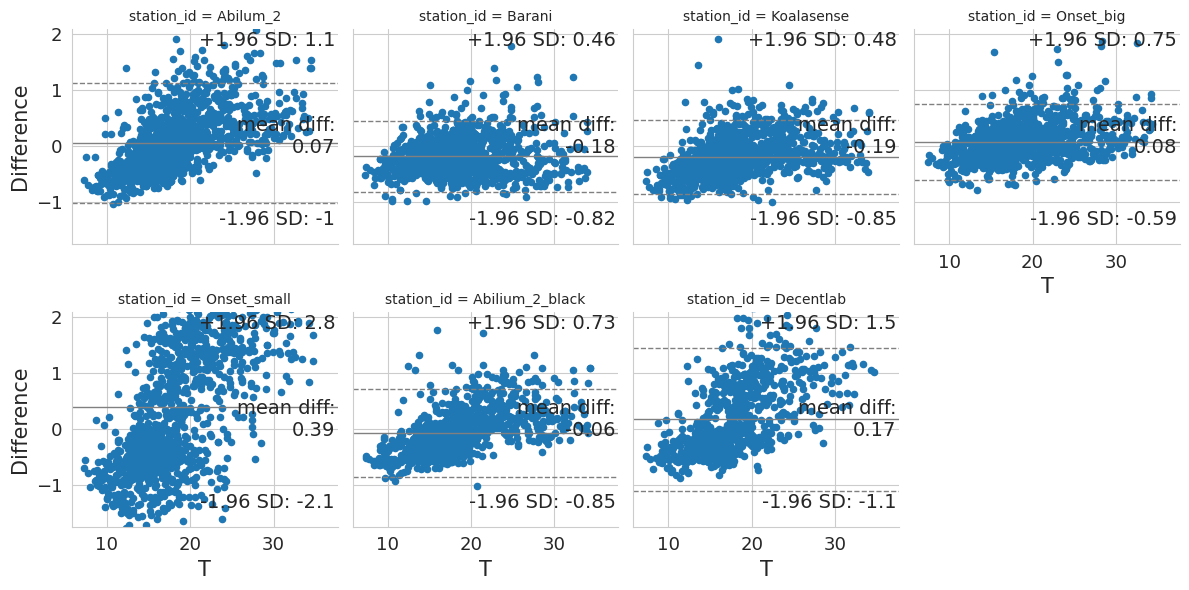

In [ ]:
# Bland Altman plot - see Bailey et al. (2020).
T_label = "T"
g = sns.FacetGrid(
    ts_df.drop(columns="Prof")
    .rename_axis(columns="station_id")
    .stack()
    .rename(T_label)
    .reset_index(level="station_id"),
    col="station_id",
    col_wrap=col_wrap,
)


def bland_altman(y, **kwargs):
    """Bland Altman plot on the current axis."""
    ax = plt.gca()
    sm.graphics.mean_diff_plot(
        y, ts_df["Prof"].loc[y.index], ax=ax, scatter_kwds=kwargs
    )


g.map(bland_altman, T_label)

The overall positive correlation in the plots suggests that the LCDs (with the exception of the Barani) tend to show a negative and positive temperature bias at lower and higher temperatures respectively.

In order to further explore the biases, we will now use [meteora](https://github.com/martibosch/meteora) to get the reference meteorological data from the MeteoSwiss Zollikofen (BER) station:

In [ ]:
client = clients.MeteoSwissClient(region)
ref_ts_df = (
    client.get_ts_df(
        [
            "temperature",
            "radiation_shortwave",
            "wind_speed",
            "wind_direction",
            "relative_humidity",
            "precipitation",
        ],
        start=ts_df.index.min(),
        end=ts_df.index.max(),
    )
    .droplevel("station_id")
    .resample("h")
    .mean()
)
ref_ts_df.head()

,temperature,radiation_shortwave,wind_speed,wind_direction,relative_humidity,precipitation
time,,,,,,
2025-07-27 00:00:00,15.533333,0.000000,2.466667,172.333333,93.116667,0.000000
2025-07-27 01:00:00,15.450000,0.000000,2.616667,170.833333,93.316667,0.016667
2025-07-27 02:00:00,15.366667,0.000000,2.000000,175.500000,93.300000,0.000000
2025-07-27 03:00:00,15.416667,0.000000,2.016667,180.333333,92.516667,0.000000
2025-07-27 04:00:00,14.883333,11.166667,1.633333,200.833333,94.316667,0.000000


We now compute a time series with the *temperature biases* ($\Delta T$), i.e., difference between the temperature measurements at each LCD and the MeteoSwiss station into a long data frame:

In [ ]:
# get diff data in long form
long_ts_df = (
    ts_df.drop(columns="Prof")
    .sub(ts_df["Prof"], axis="rows")
    .rename_axis(columns="station_id")
    .stack()
    .rename(y_col)
    .reset_index()
)
long_ts_df.head()

,time,station_id,$\Delta$T
0,2025-07-27,Abilum_2,-0.480308
1,2025-07-27,Barani,-0.333333
2,2025-07-27,Koalasense,-0.400000
3,2025-07-27,Onset_big,-0.199333
4,2025-07-27,Onset_small,-0.673333


Our main hypotheses are that:
- biases follow a daily cycle
- radiation is the main driver of the biases

Let us now plot the daily cycle of the average bias and radiation to test our hypothesis:

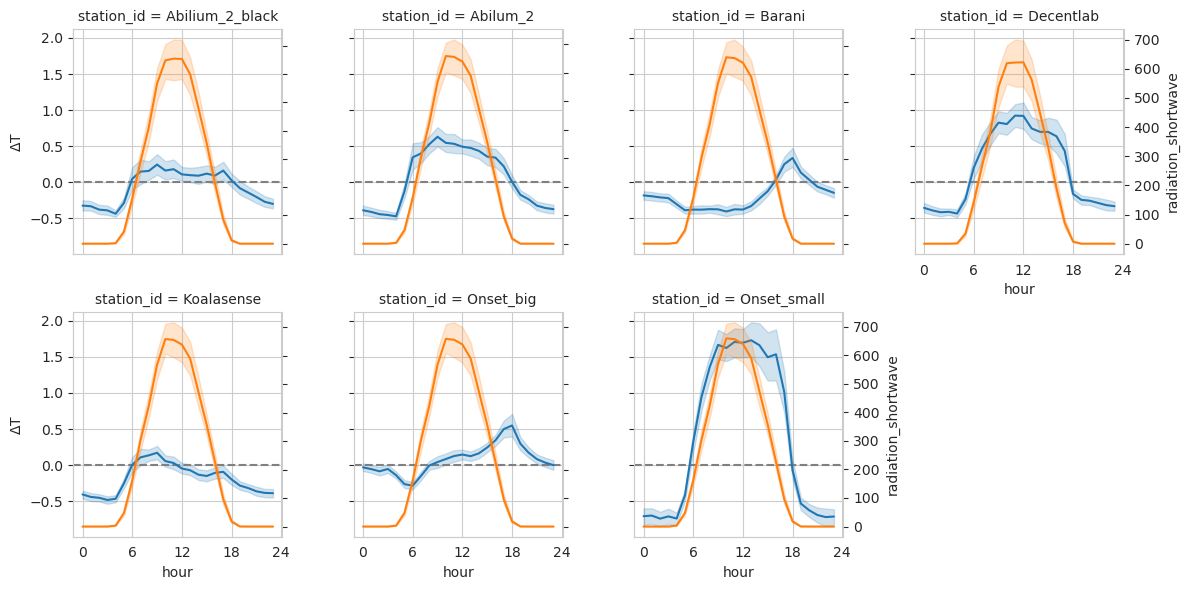

In [ ]:
variable = "radiation_shortwave"
daily_ts_df = (
    long_ts_df.set_index("time")
    .groupby("station_id")
    .resample("h")
    .mean()
    .reset_index()
)
daily_ts_df["hour"] = daily_ts_df["time"].dt.hour

g = plot_utils.facet_twinx_lineplot(
    daily_ts_df, ref_ts_df, variable, y_col, col_wrap=col_wrap
)

At a first glance, our hypothesis seems valid for all the LCDs with the exception of Barani and Onset big. However, for Abilium 2 black and Koalasense it seems that the effect of the radiation on $\Delta T$ is blocked at a certain point after which additional radiation does not result in higher biases. The confidence intervals are quite narrow which suggests that this pattern is consistent throughout our study period.

## Interlude: clustering days based on reference meteorological data to test bias consistency

To further confirm the consistency, we will cluster the days of our study period by their (standardize) time series of observation of the reference variables measured at the MeteoSwiss station:

K=1 skipped. Mean computed from data directly.
K=2 fitted in 0.015 seconds.
K=3 fitted in 0.013 seconds.
K=4 fitted in 0.013 seconds.
K=5 fitted in 0.010 seconds.
K=6 fitted in 0.012 seconds.
K=7 fitted in 0.017 seconds.


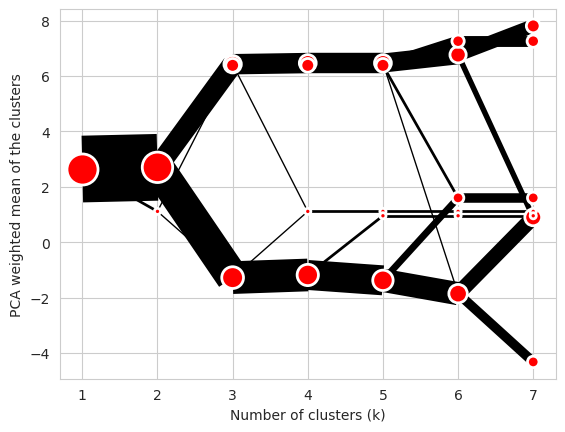

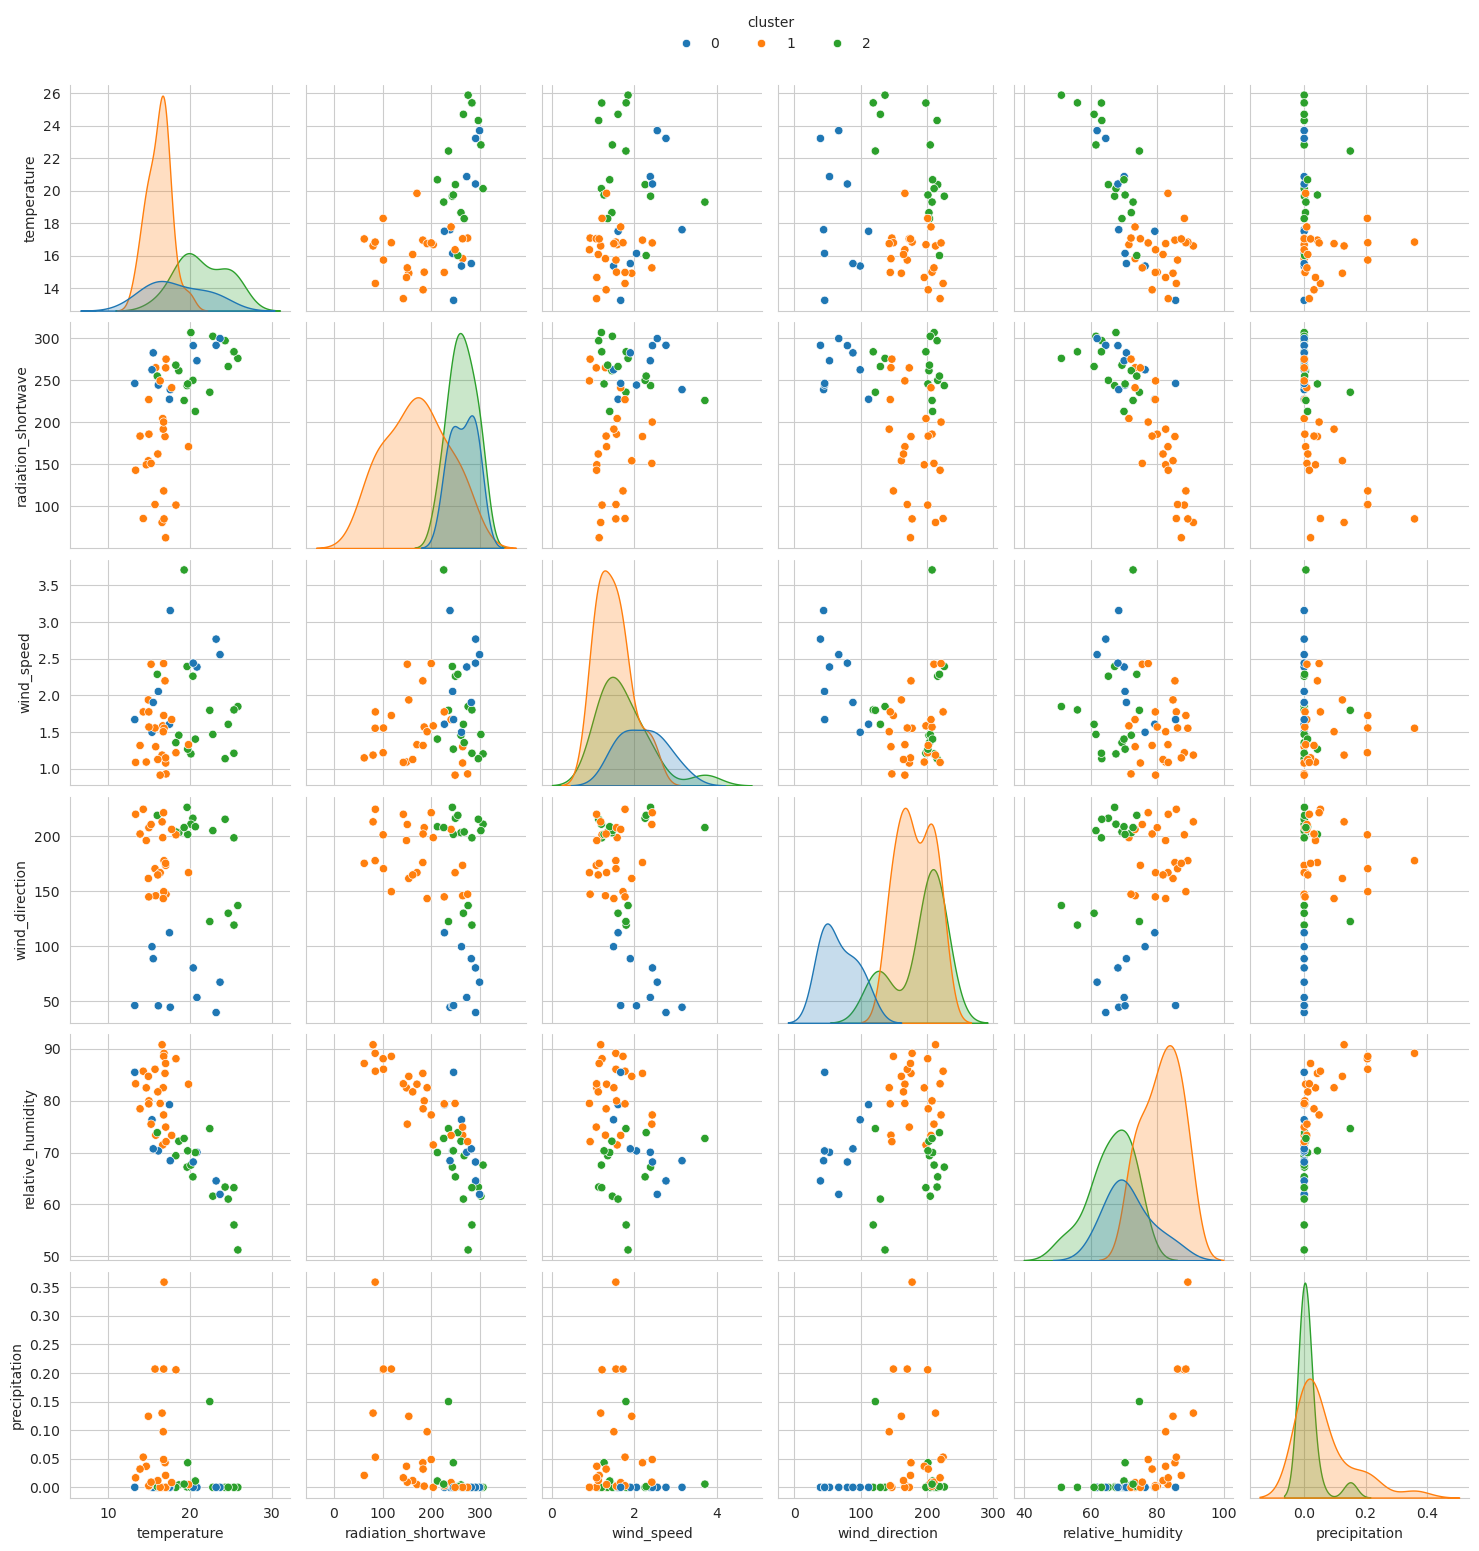

In [ ]:
X_ser = (
    pd.DataFrame(
        preprocessing.StandardScaler().fit_transform(ref_ts_df),
        index=ref_ts_df.index,
        columns=ref_ts_df.columns,
    )
    .groupby(ref_ts_df.index.date)
    .apply(lambda col_ser: col_ser.T.values)
    .apply(lambda arr: arr.flatten())
)
X_arr = np.stack(X_ser.values)
k_range = range(1, 8)
random_seed = 0
cgram = clustergram.Clustergram(k_range, random_state=random_seed).fit(X_arr)
cgram.plot()
score = cgram.davies_bouldin_score()
n_clusters = score.idxmax()
cluster_ser = pd.Series(cgram.labels_[n_clusters].values, index=X_ser.index)
g = sns.pairplot(
    ref_ts_df.resample("d").mean().assign(**{"cluster": cluster_ser}),
    hue="cluster",
    palette=sns.color_palette(n_colors=n_clusters),
)
sns.move_legend(
    g, "lower center", bbox_to_anchor=(0.5, 1), ncol=n_clusters, frameon=False
)

The clustering suggests three main types of days, namely:
- **cluster 0**: days with *mean wind direction under 120$\degree$ (N to SE)*
- **cluster 1**: days with mean wind direction over 120$\degree$ with *low mean temperature and radiation* and *high relative humidity*
- **cluster 2**: days with mean wind direction over 120$\degree$ with *high mean temperature and radiation* and *low relative humidity*

Let us now re-assess the daily cycle of $\Delta T$ for each day cluster:

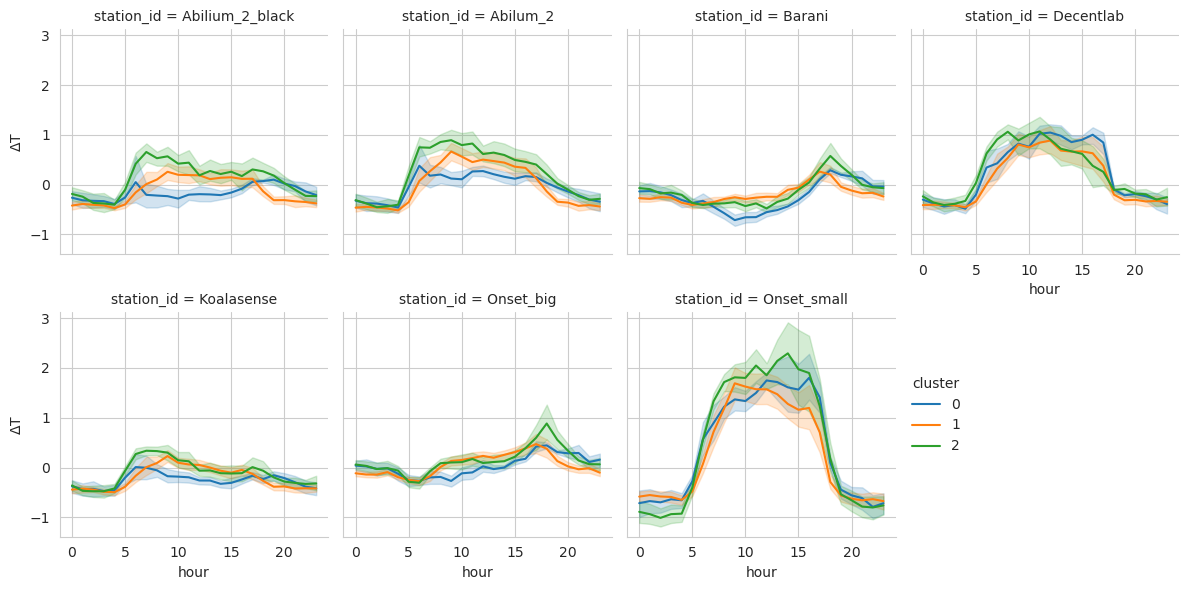

In [ ]:
g = sns.FacetGrid(
    daily_ts_df.assign(**{"cluster": daily_ts_df["time"].dt.date.map(cluster_ser)}),
    col="station_id",
    col_wrap=col_wrap,
    hue="cluster",
)
g.map_dataframe(sns.lineplot, x="hour", y=y_col)
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.75, 0.3))

There do not seem to be major differences in the $\Delta T$ daily cycle throughout day types.

## Modeling temperature biases based on radiation

We will now focus on modeling $\Delta T$ based on the (shortwave) radiation *for each LCD separately*. The rationale is that we expect each LCD to respond to radiation at different time lags and scales.

In line with Bell et al. (2015) [2], we will compute the sum of the previous radiation using different windows ranging from 1 to 5 hours and then, test which scale shows the highest correlation (based on the Pearson correlation coefficient) with $\Delta T$. Therefore, each LCD will have a dedicated model to predict its $\Delta T$ with the previous radiation (computed out of its *LCD-specific time window*) as independent variable.

Let us start by preparing the regression data as a long data frame:

In [ ]:
msr = regr_utils.MultiScaleRegression(ref_ts_df)
max_window_hours = 5
# window_minutes = [15, 30] + [60 * i for i in range(1, max_window_hours + 1)]
window_minutes = [60 * i for i in range(1, max_window_hours + 1)]
X_df = (
    long_ts_df.groupby("station_id")
    .apply(
        lambda station_ts_df: msr.get_regr_df(
            station_ts_df,
            y_col,
            window_minutes,
            variables=["radiation_shortwave"],
            add_scale_to_col_name=True,
            rescale=False,
        ),
        include_groups=False,
    )
    .droplevel(1)
    .reset_index()
)
# X_df = X_df[X_df["radiation_shortwave"] > 0]
# stack radiation columns into single column and keep scale at a separate column
X_df = X_df.melt(
    id_vars=X_df.columns[~X_df.columns.str.startswith("radiation_shortwave")],
    var_name="scale",
    value_name="radiation_shortwave",
)
X_df["scale"] = X_df["scale"].str.split("_").str[-1].astype(int)
# drop nan values
X_df = X_df.dropna()
# # use a scaled copy for plots
X_scaled_df = X_df.copy()
X_scaled_df["radiation_shortwave"] = (
    X_df.groupby("station_id")["radiation_shortwave"]
    .apply(
        lambda ser: pd.Series(
            preprocessing.StandardScaler().fit_transform(ser.to_frame()).flatten(),
            index=ser.index,
        )
    )
    .reset_index(drop=True)
    .values
)
# set the station-window scale mapping as a dict
station_scale_dict = X_df.groupby("station_id")["scale"].first().to_dict()
# show the data frame
X_df.head()

,station_id,time,$\Delta$T,scale,radiation_shortwave
0,Abilium_2_black,2025-08-07 13:00:00,0.579717,180,2537.500000
1,Abilium_2_black,2025-08-07 14:00:00,0.280774,180,2344.833333
2,Abilium_2_black,2025-08-07 15:00:00,0.341697,180,2004.666667
3,Abilium_2_black,2025-08-07 16:00:00,0.487167,180,1575.833333
4,Abilium_2_black,2025-08-07 17:00:00,0.783993,180,1084.500000


We can see the scale/previous window size (in minutes) selected for each station:

In [ ]:
station_scale_dict

{'Abilium_2_black': 180,
 'Abilum_2': 60,
 'Barani': 300,
 'Decentlab': 120,
 'Koalasense': 60,
 'Onset_big': 300,
 'Onset_small': 120}

We can start with an ordinary-least squares (OLS) linear regression model:

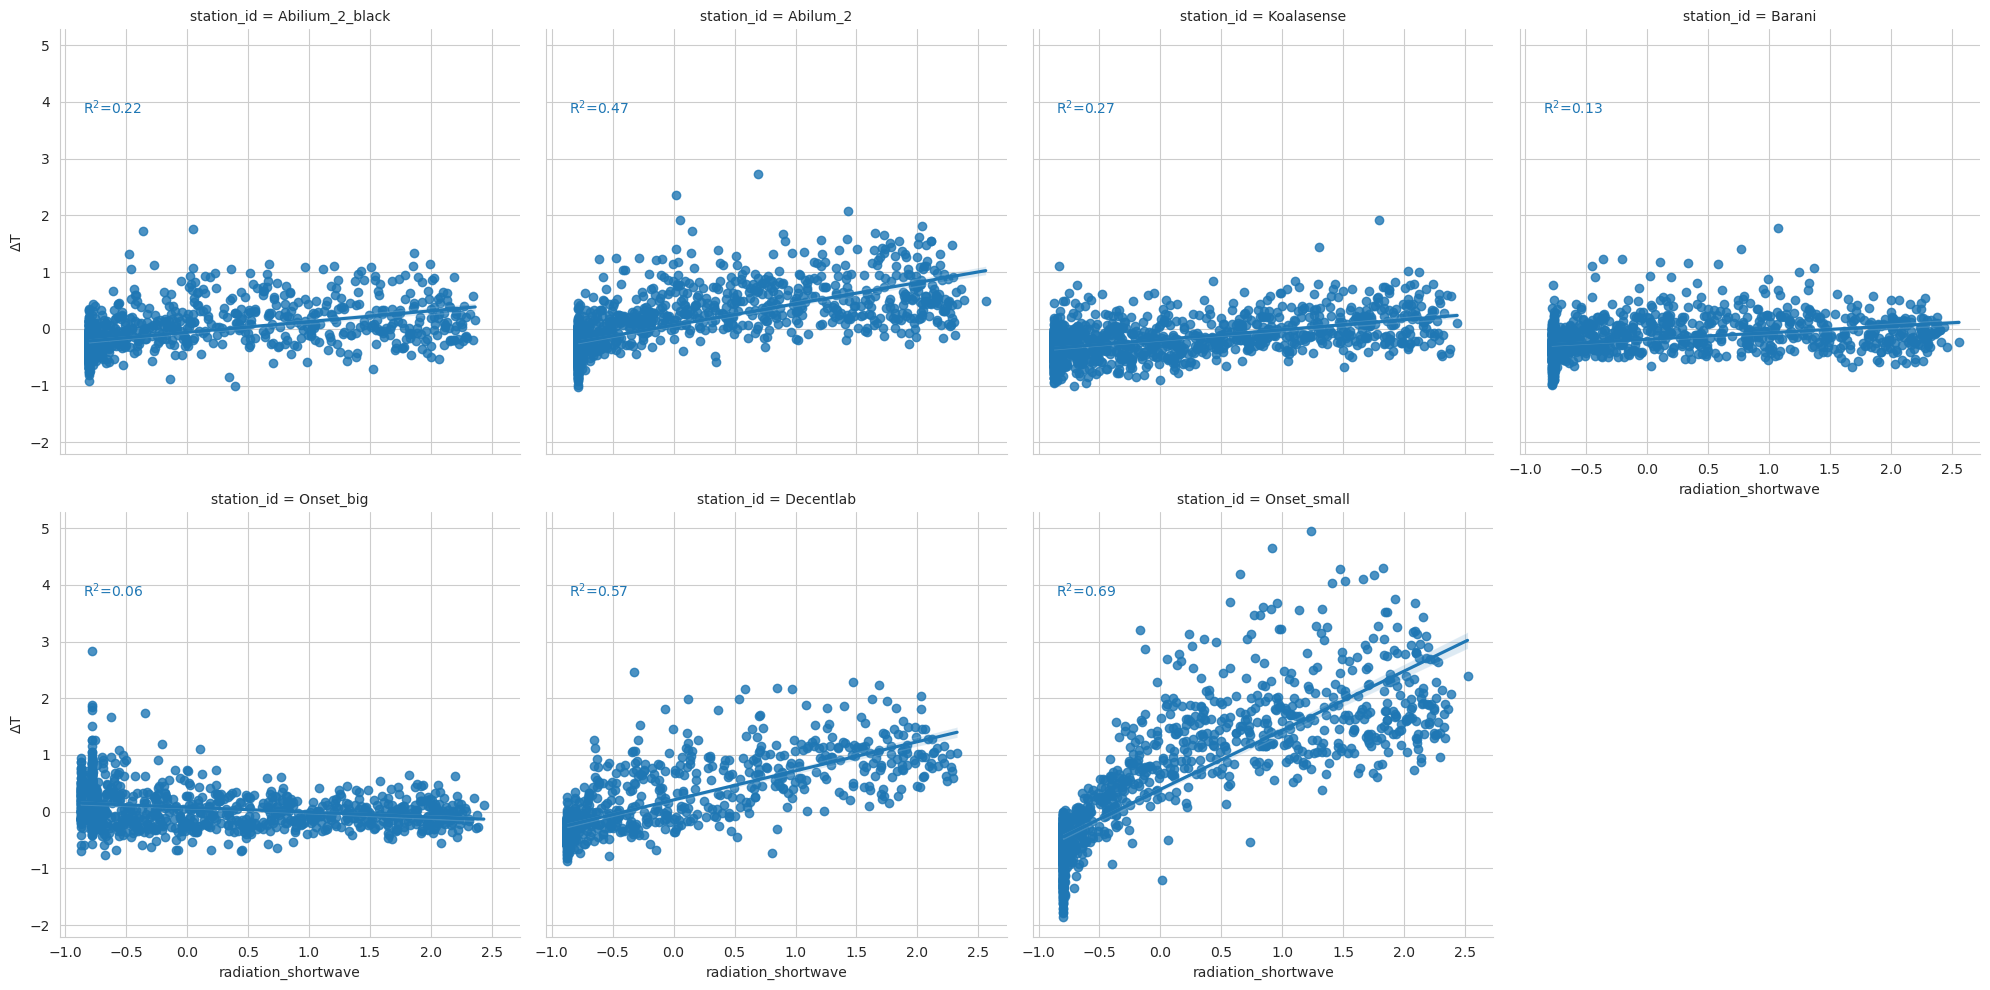

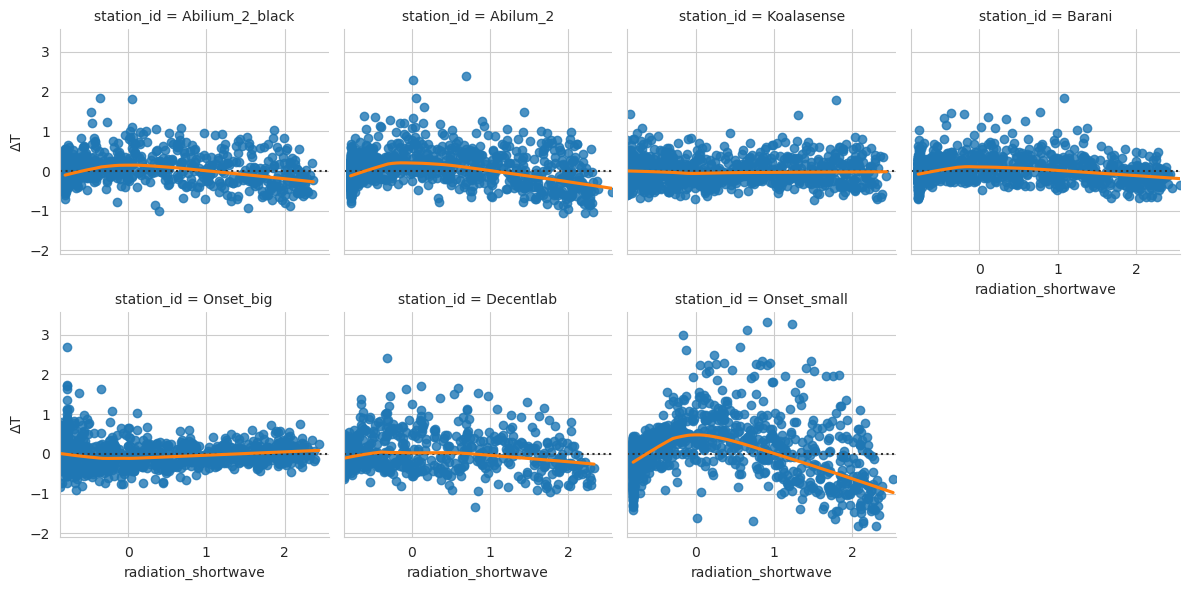

In [ ]:
# OLS
g = sns.lmplot(
    X_scaled_df,
    x="radiation_shortwave",
    y=y_col,
    col="station_id",
    col_wrap=col_wrap,
    # hue="cluster",
)
g.map_dataframe(plot_utils.r2_annotate, x="radiation_shortwave", y=y_col)
# g.add_legend()

# residuals
g = sns.FacetGrid(
    X_scaled_df,
    col="station_id",
    col_wrap=col_wrap,
    # hue="cluster",
)
g.map(
    sns.residplot,
    "radiation_shortwave",
    y_col,
    lowess=True,
    line_kws=dict(color=sns.color_palette()[1]),
)

As we can see, all models show a low to moderate fit with the exception of the Barani and Onset big, whose biases' daily cycle did not initially show a clear relationship with the radiation. The plots of the residuals suggest that there is still underlying structure (note the LOWESS curve [3], especially for the Onset small LCD), thus breaking the linear regression assumption that they are independent and identically distributed (i.i.d.).

We can also test fitting a separate model for each day cluster:

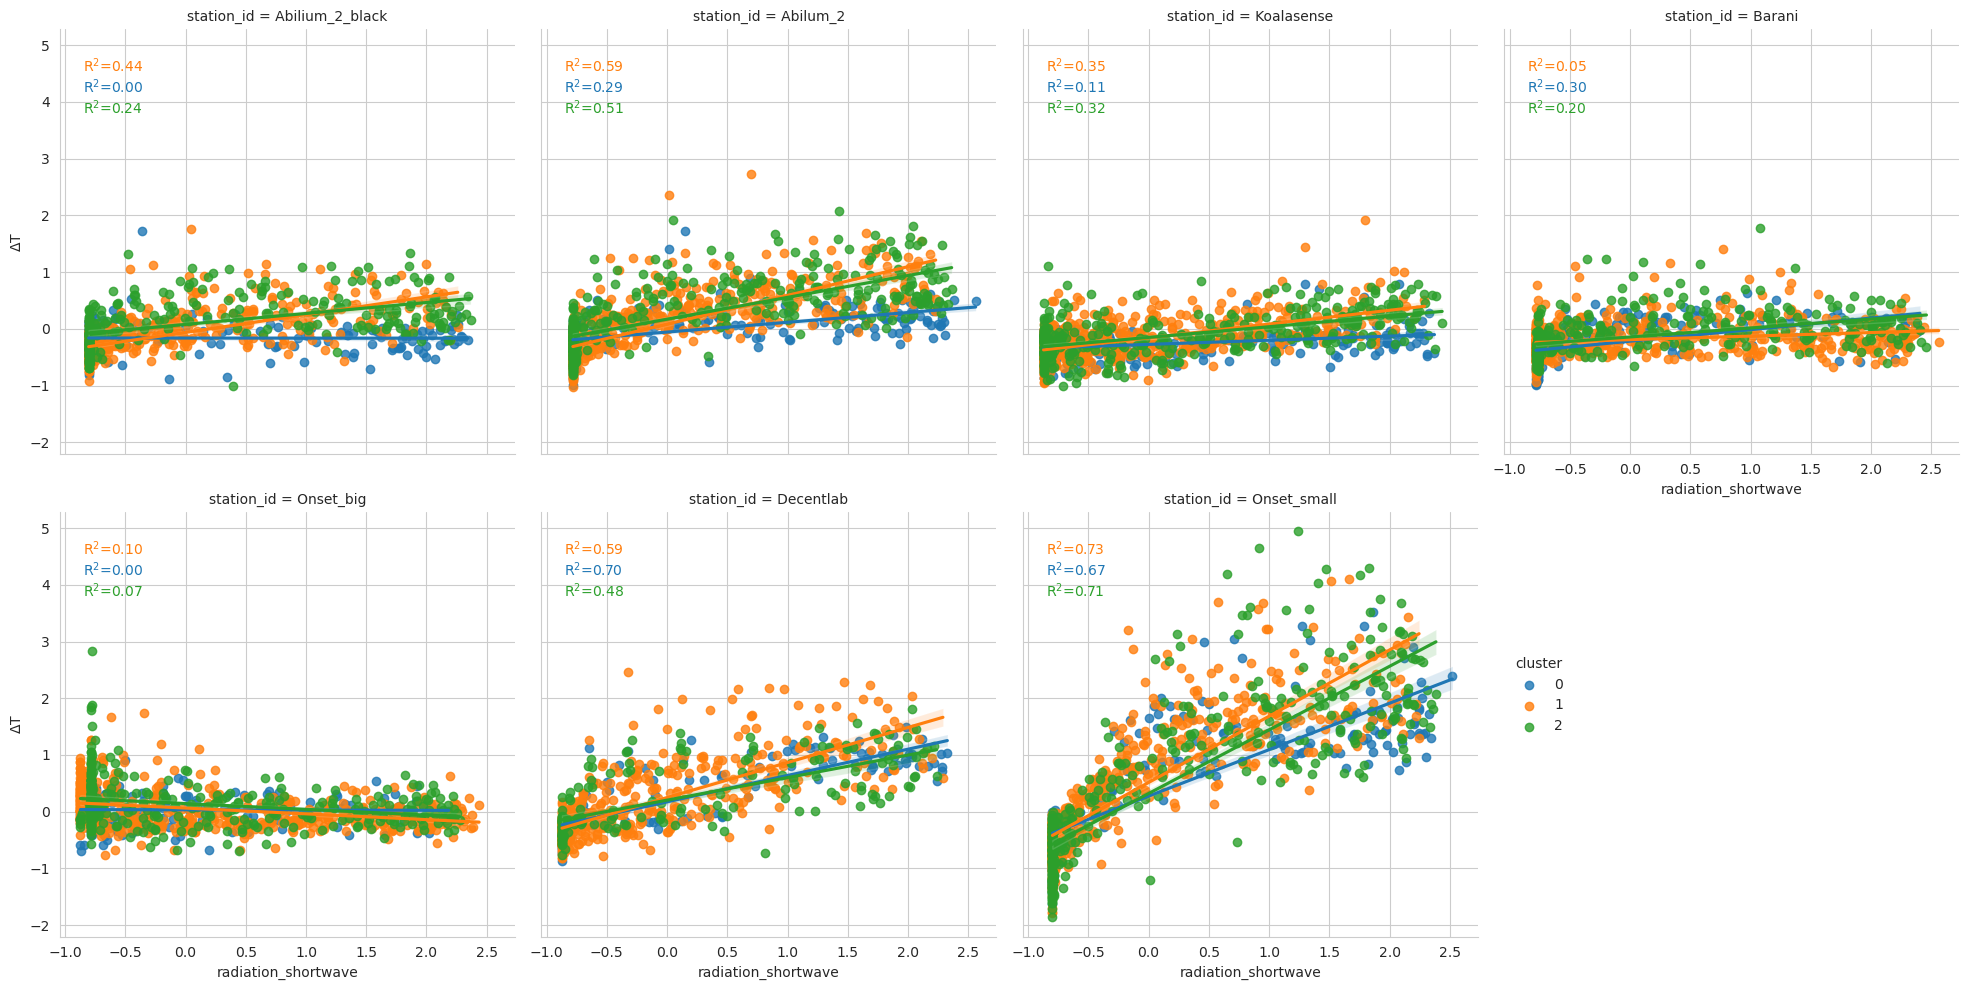

In [ ]:
# OLS by day cluster
plot_df = X_scaled_df.assign(**{"cluster": X_df["time"].dt.date.map(cluster_ser)})
g = sns.lmplot(
    plot_df,
    x="radiation_shortwave",
    y=y_col,
    col="station_id",
    col_wrap=col_wrap,
    hue="cluster",
)
g.map_dataframe(
    plot_utils.ols_annotate,
    x="radiation_shortwave",
    y=y_col,
    labels=plot_df["cluster"].unique(),
)
# g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.75, 0.3))

With the exception of the Barani and Decentlab LCDs, the OLS model seems to show the strongest fits for days with wind direction over 120$\degree$, i.e., clusters 1 and 2 (even though for the Onset small there is very little difference).

While the differences in the fits observed throughout day clusters may suggest non-linear relationships as well as effects of other variables, fitting a separate model for each day cluster may simply constitute an example of overfitting. Instead, following Cornes et al. (2020) [4], we can improve the models in two main ways. First, in order to better represent non-linear effects, we can change the linear regression to a generalized additive model (GAM), where the linear terms are replaced by *penalized B splines*. Secondly, an autoregressive term can be added to the regression in order to address the temporal autocorrelation of the observations and (ideally) satisfy the i.i.d assumption.

#### TODO: *for each station*: (i) use `statsmodels.tsa.stattools.acf` to test for temporal autocorrelation, and (ii) use `statsmodels.graphics.tsaplots.plot_acf` to show that the 1-hour lag shows the strongest correlation or (iii) use `statsmodels.tsa.ar_model.ar_select_order`.

Let us compare the performance of:
- **OLS**: an univariate linear regression model
- **GAM**: an univariate GAM
- **GAM (AR)**: a GAM with an autoregressive term

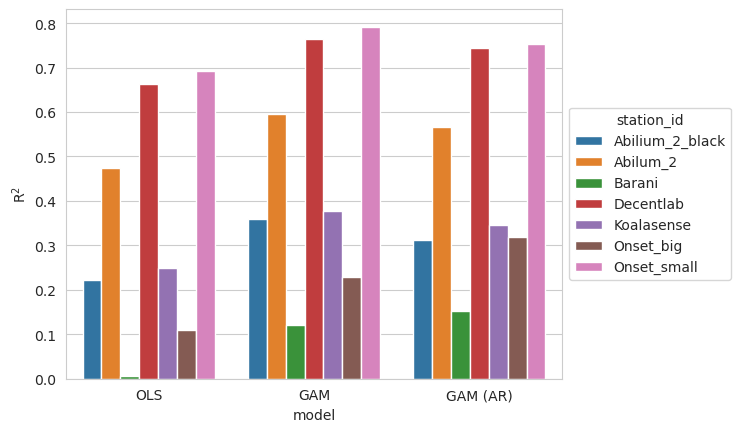

In [ ]:
# define models to compare
# compose.ForecastingPipeline
ols = pipeline.Pipeline(
    steps=[
        # ("imputer", Imputer(method="mean")),
        ("scaler", preprocessing.StandardScaler()),
        ("model", linear_model.LinearRegression()),
    ]
)
gam = pipeline.Pipeline(
    steps=[
        # ("imputer", Imputer(method="mean")),
        ("scaler", preprocessing.StandardScaler()),
        ("transformer", preprocessing.SplineTransformer(degree=3, n_knots=20)),
        ("model", linear_model.LinearRegression()),
    ]
)
# _sarimax = compose.ForecastingPipeline(
#     steps=[
#         # ("imputer", Imputer(method="mean")),
#         ("scaler", preprocessing.StandardScaler()),
#         ("model", sarimax.SARIMAX()),
#     ]
# )
gam_ar = compose.ForecastingPipeline(
    steps=[
        # ("imputer", Imputer(method="mean")),
        ("scaler", preprocessing.StandardScaler()),
        ("transformer", preprocessing.SplineTransformer(degree=3, n_knots=20)),
        ("model", auto_reg.AutoREG(lags=1, trend="c")),
    ]
)
# model_dict = {"OLS": ols, "GAM": gam, "SARIMAX": _sarimax, "GAM (AR)": gam_ar}
model_dict = {"OLS": ols, "GAM": gam, "GAM (AR)": gam_ar}

# compare them
res_df, fit_df, fit_model_dict = regr_utils.compare_models(
    X_df, model_dict, y_col, ["radiation_shortwave"]
)

# plot comparison
ax = sns.barplot(
    fit_df.reset_index().melt(
        id_vars=["station_id"], var_name="model", value_name="R$^2$"
    ),
    x="model",
    y="R$^2$",
    hue="station_id",
)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

Using a GAM notably improves the strength of the fit, whereas further adding an autoregressive term results in better fit for the Barani and Onset (big) LCDs but worse for the rest.

Additionally, we can explore whether these improvements are consistent across the day clusters:

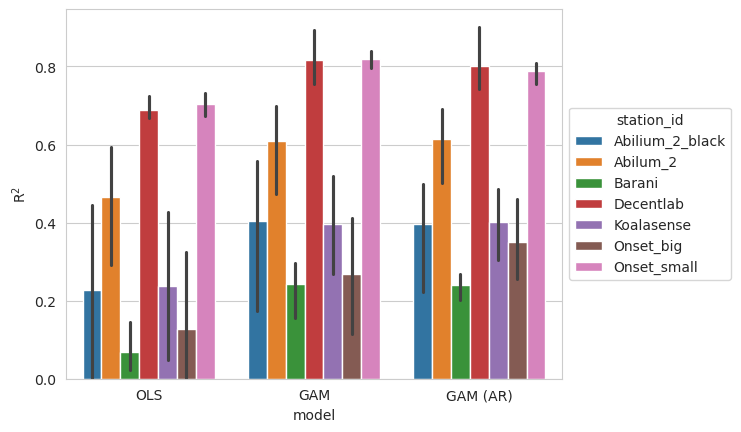

In [ ]:
res_dfs = []
fit_dfs = []
for cluster_label, cluster_df in X_df.groupby(X_df["time"].dt.date.map(cluster_ser)):
    _res_df, _fit_df, _ = regr_utils.compare_models(
        cluster_df, model_dict, y_col, ["radiation_shortwave"]
    )
    res_dfs.append(_res_df.assign(**{"cluster_label": cluster_label}))
    fit_dfs.append(_fit_df.assign(**{"cluster_label": cluster_label}))
cluster_res_df = pd.concat(res_dfs)
cluster_fit_df = pd.concat(fit_dfs)

# g = sns.FacetGrid(
#     fit_df.reset_index().melt(
#         id_vars=["station_id", "cluster_label"], var_name="model", value_name="R$^2$"
#     ),
#     col="station_id",
#     col_wrap=col_wrap,
# )
# g.map_dataframe(sns.barplot, x="model", y="R$^2$", hue="cluster_label")
# g.add_legend()

# fit_df.plot(kind="bar")
ax = sns.barplot(
    cluster_fit_df.reset_index().melt(
        id_vars=["station_id", "cluster_label"], var_name="model", value_name="R$^2$"
    ),
    x="model",
    y="R$^2$",
    hue="station_id",
)
sns.move_legend(ax, "center left", bbox_to_anchor=(1, 0.5))

It seems that the GAM consistently improves the strengths of the fits, while the autoregressive term has little effect. We can further compare the OLS and the GAM models with (i) a scatter plot of the predicted versus observed values and (ii) a plot of the residuals against the radiation:

<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_947958/1048700083.py:4: SyntaxWarning: invalid escape sequence '\h'
  yhat_col = "$\hat{\Delta T}$"


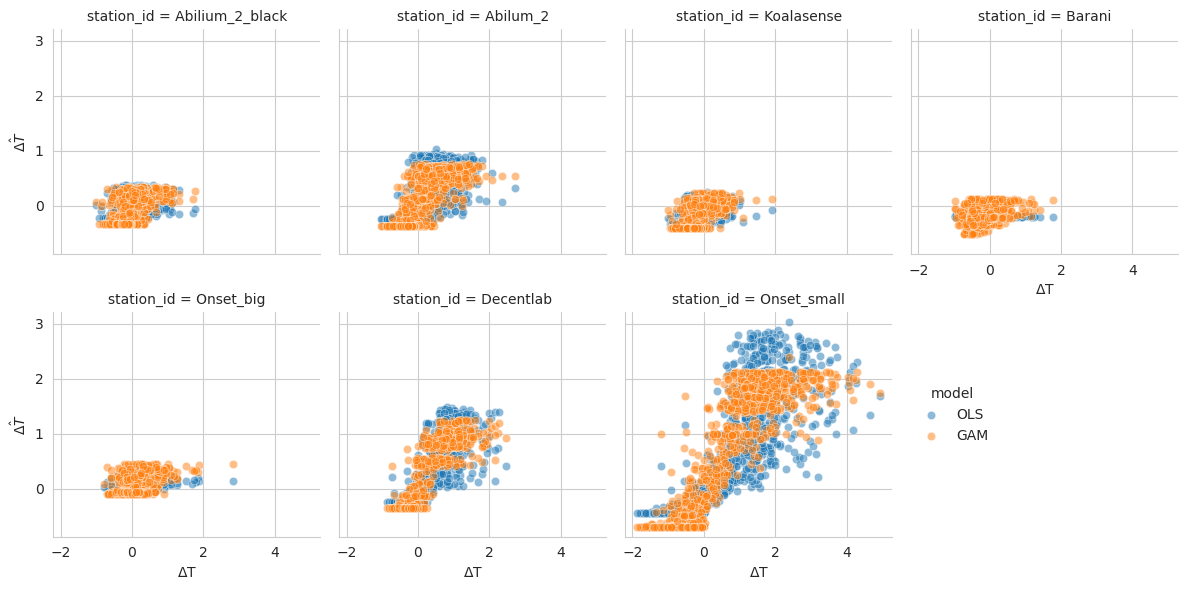

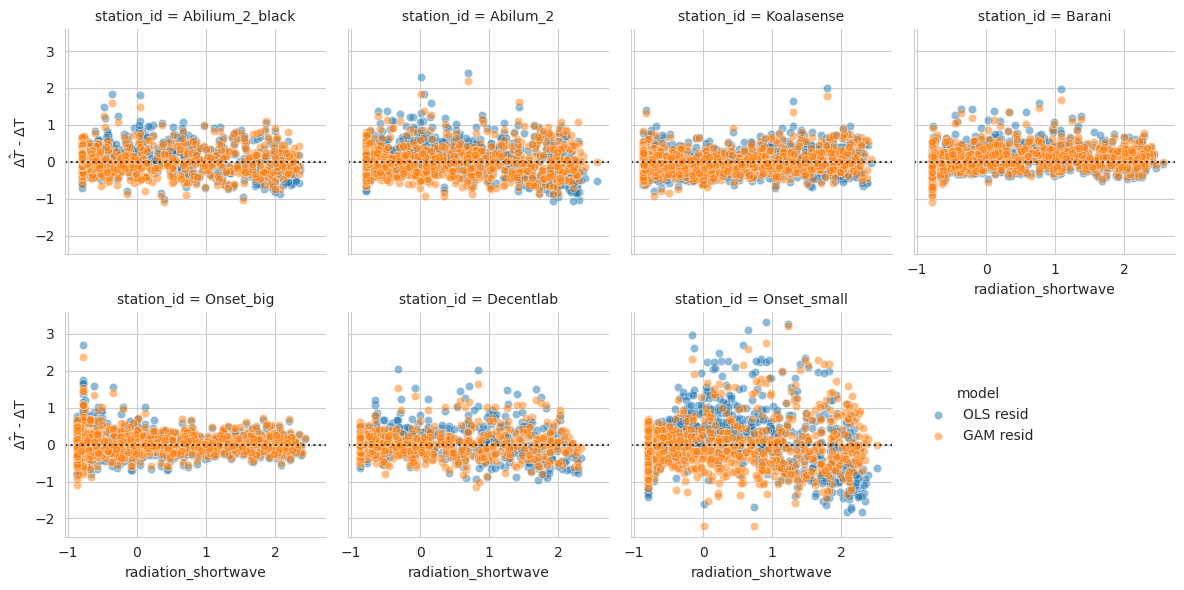

In [ ]:
id_vars = ["station_id", "radiation_shortwave", y_col]
var_name = "model"
model_cols = ["OLS", "GAM"]
yhat_col = "$\hat{\Delta T}$"
plot_df = res_df.assign(
    **{
        "station_id": X_df["station_id"],
        "radiation_shortwave": X_scaled_df["radiation_shortwave"],
        y_col: X_df[y_col],
    }
)
# obs/pred scatterplot
g = sns.FacetGrid(
    plot_df[id_vars + model_cols].melt(
        id_vars=id_vars,
        var_name=var_name,
        value_name=yhat_col,
    ),
    col="station_id",
    col_wrap=col_wrap,
    hue="model",
)
g.map(sns.scatterplot, y_col, yhat_col, alpha=0.5)
# g.map(sns.scatterplot, "radiation_shortwave", y_col)
# for station_id, ax in g.axes_dict.items():
#     sm.graphics.plot_fit(
#         model_dict[station_id], "radiation_shortwave", vlines=False, ax=ax
#     )
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.75, 0.3))

# residuals scatterplot
value_name = f"{yhat_col} - {y_col}"
# model_cols = ["OLS", "GAM (AR)"]
g = sns.FacetGrid(
    plot_df.assign(
        **{f"{model} resid": plot_df[y_col] - plot_df[model] for model in model_cols},
    )[id_vars + [f"{model} resid" for model in model_cols]].melt(
        id_vars=id_vars, var_name="model", value_name=value_name
    ),
    col="station_id",
    col_wrap=col_wrap,
    hue="model",
)
g.map(sns.scatterplot, "radiation_shortwave", value_name, alpha=0.5)
# add line at 0
for ax in g.axes.flat:
    ax.axhline(0, ls=":", c=".2")
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.75, 0.3))

We can visually confirm that the GAM model shows a better fit and removes structure from the residuals. Let us conclude by showing the daily cycle of the observed and predicted biases:

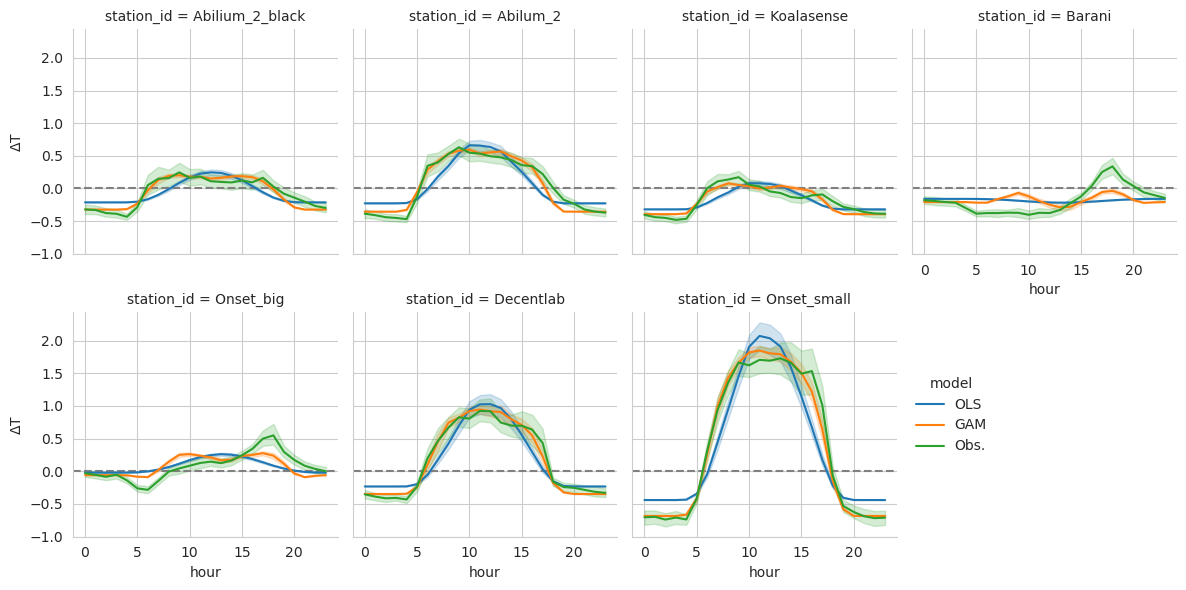

In [ ]:
g = sns.FacetGrid(
    pd.concat(
        [
            plot_df.assign(**{"time": X_df["time"]}).set_index(["station_id", "time"])[
                model_cols
            ],
            daily_ts_df.set_index(["station_id", "time"])[[y_col, "hour"]].rename(
                columns={y_col: "Obs."}
            ),
        ],
        axis="columns",
    )
    .reset_index()
    .melt(id_vars=["station_id", "time", "hour"], var_name="model", value_name=y_col),
    col="station_id",
    hue="model",
    col_wrap=col_wrap,
)
for ax in g.axes.flat:
    # add horizontal line at 0
    ax.axhline(0, color="gray", linestyle="--")
g.map(sns.lineplot, "hour", y_col)
g.add_legend()
sns.move_legend(g, "center", bbox_to_anchor=(0.75, 0.3))

We can observe also here that the daily cycle of the GAM predictions is closer to the observed values than its OLS counterparts.

Accordingly, *for each station* we will save the GAM pipeline to disk so that we can use them to correct radiative biases in separate notebooks:

In [ ]:
model_label = "GAM"
station_model_dict = {}
for station_id, _model_dict in fit_model_dict.items():
    model_filename = f"{station_id}-gam.skops"
    model_filepath = path.join(models_dir, model_filename)
    io.dump(_model_dict[model_label], model_filepath)
    print(f"Saved GAM model for {station_id} to {model_filepath}")
    station_model_dict[station_id] = model_filename

# save dict of station models
with open(dst_station_model_dict_filepath, "w") as dst:
    json.dump(station_model_dict, dst)

Saved GAM model for Abilium_2_black to ../models/Abilium_2_black-gam.skops
Saved GAM model for Abilum_2 to ../models/Abilum_2-gam.skops
Saved GAM model for Barani to ../models/Barani-gam.skops
Saved GAM model for Decentlab to ../models/Decentlab-gam.skops
Saved GAM model for Koalasense to ../models/Koalasense-gam.skops
Saved GAM model for Onset_big to ../models/Onset_big-gam.skops
Saved GAM model for Onset_small to ../models/Onset_small-gam.skops


We also need to save the scale dictionary to a file so that we can subsequently know how to compute the independent variables:

In [ ]:
with open(dst_station_scale_dict_filepath, "w") as dst:
    json.dump(station_scale_dict, dst)

## References

1. Bailey, E., Fuhrmann, C., Runkle, J., Stevens, S., Brown, M., & Sugg, M. (2020). Wearable sensors for personal temperature exposure assessments: a comparative study. Environmental research, 180, 108858.
2. Bell, S., Cornford, D., & Bastin, L. (2015). How good are citizen weather stations? Addressing a biased opinion. Weather, 70(3), 75-84.
3. Cleveland, W. S. (1979). Robust locally weighted regression and smoothing scatterplots. Journal of the American statistical association, 74(368), 829-836.
4. Cornes, R. C., Dirksen, M., & Sluiter, R. (2020). Correcting citizen‐science air temperature measurements across the Netherlands for short wave radiation bias. Meteorological Applications, 27(1), e1814.